## ============================================
## CREDIT CARD USAGE SEGMENTATION 
## ============================================

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import joblib

## 1️⃣ Load and Explore Data

In [14]:
print("🔹 Loading dataset...")

data = pd.read_csv("data/Customer Data.csv")

print("\n✅ Dataset loaded successfully!")
print("Shape:", data.shape)
print("\nFirst 5 rows:\n", data.head())

# Drop customer ID if present
if "CUST_ID" in data.columns:
    data = data.drop("CUST_ID", axis=1)

# Fill missing values
data = data.fillna(data.mean())

🔹 Loading dataset...

✅ Dataset loaded successfully!
Shape: (8950, 18)

First 5 rows:
   CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001    40.900749           0.818182      95.40              0.00   
1  C10002  3202.467416           0.909091       0.00              0.00   
2  C10003  2495.148862           1.000000     773.17            773.17   
3  C10004  1666.670542           0.636364    1499.00           1499.00   
4  C10005   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0               


📊 Showing EDA visualizations...


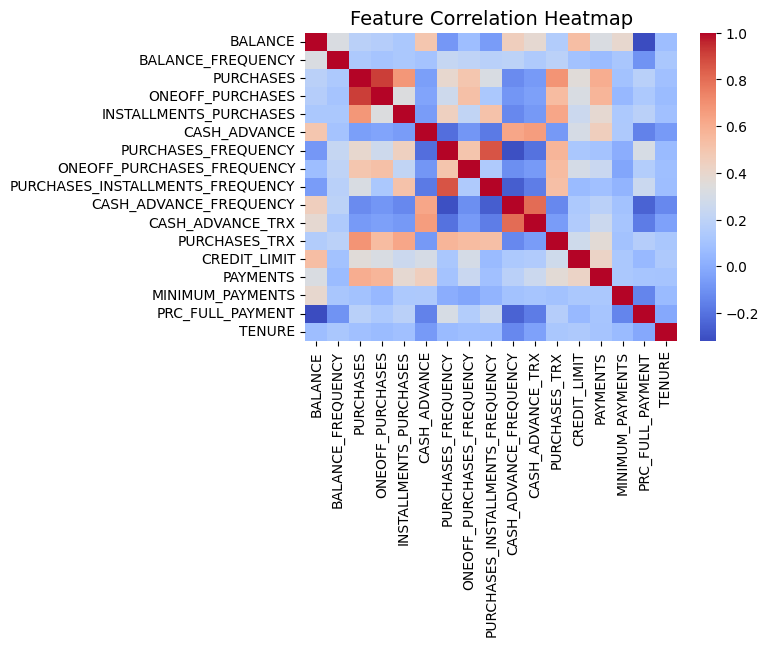

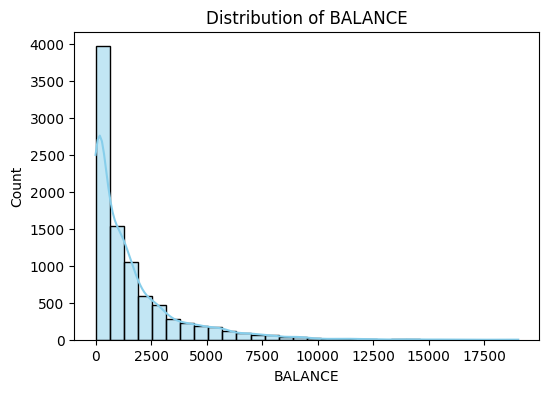

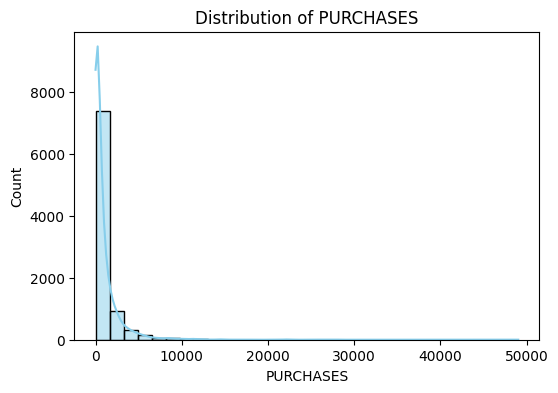

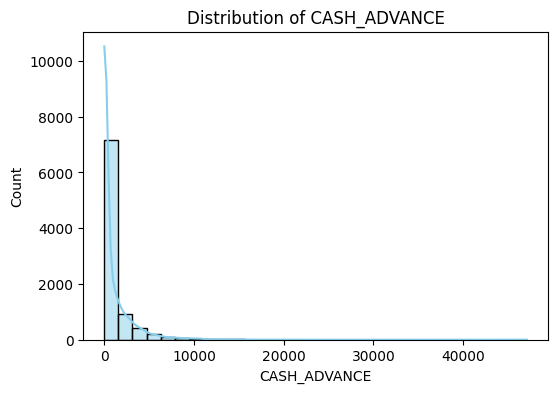

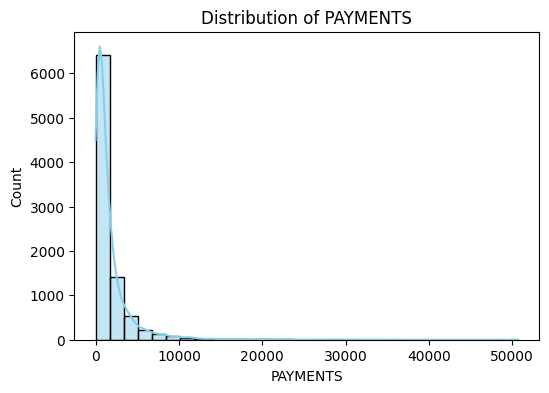

In [30]:
print("\n📊 Showing EDA visualizations...")

# Correlation heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(data.corr(), annot=False, cmap="coolwarm")
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.show()

# Distribution of selected features
num_features = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "PAYMENTS"]
for col in num_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(data[col], bins=30, kde=True, color="skyblue")
    plt.title(f"Distribution of {col}")
    plt.show()

## 2️⃣ Data Preprocessing

In [15]:
print("\n🔹 Scaling and reducing dimensions...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("✅ Preprocessing complete. PCA reduced data shape:", X_pca.shape)



🔹 Scaling and reducing dimensions...
✅ Preprocessing complete. PCA reduced data shape: (8950, 2)


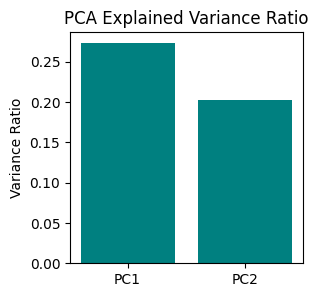

In [25]:
# PCA variance visualization
plt.figure(figsize=(3, 3))
plt.bar(["PC1", "PC2"], pca.explained_variance_ratio_, color="teal")
plt.title("PCA Explained Variance Ratio")
plt.ylabel("Variance Ratio")
plt.show()

## 3️⃣ Clustering Models

In [16]:
# --- KMeans ---
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_pca)

# --- DBSCAN ---
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_pca)

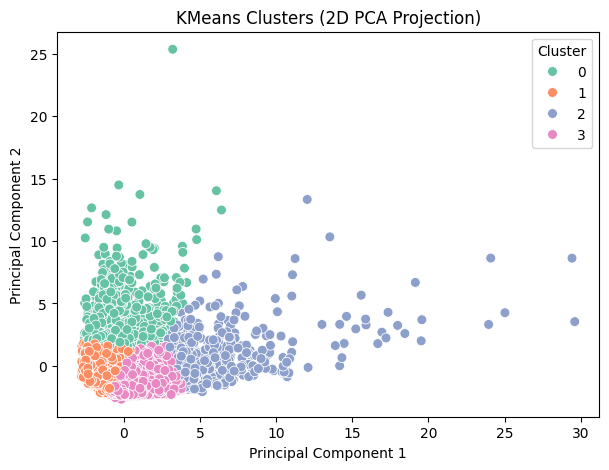

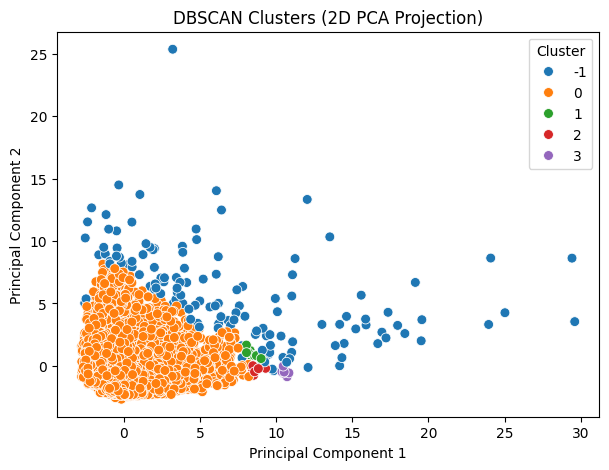

In [26]:
# KMeans clusters
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_kmeans, palette="Set2", s=50)
plt.title("KMeans Clusters (2D PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

# DBSCAN clusters
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_dbscan, palette="tab10", s=50)
plt.title("DBSCAN Clusters (2D PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

## 4️⃣ Evaluate Cluster Performance

In [17]:
print("\n🔹 Evaluating clustering performance...")

def evaluate_model(name, X, labels):
    if len(set(labels)) <= 1:
        return {"Model": name, "Silhouette": None, "Davies-Bouldin": None, "Calinski-Harabasz": None}
    return {
        "Model": name,
        "Silhouette": silhouette_score(X, labels),
        "Davies-Bouldin": davies_bouldin_score(X, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X, labels)
    }

results = []
results.append(evaluate_model("KMeans", X_pca, labels_kmeans))
results.append(evaluate_model("DBSCAN", X_pca, labels_dbscan))

results_df = pd.DataFrame(results)
print("\n📊 Cluster Evaluation Results:\n", results_df)

results_df.to_csv("data/cluster_performance.csv", index=False)
print("✅ Evaluation results saved to 'data/cluster_performance.csv'")


🔹 Evaluating clustering performance...

📊 Cluster Evaluation Results:
     Model  Silhouette  Davies-Bouldin  Calinski-Harabasz
0  KMeans    0.407668        0.800665        5822.816324
1  DBSCAN    0.626753        1.167705         519.550279
✅ Evaluation results saved to 'data/cluster_performance.csv'


## 5️⃣ Business Insights (Cluster Profiling)

In [18]:
print("\n🔹 Generating business insights from KMeans clusters...")

clustered_data = data.copy()
clustered_data["Cluster"] = labels_kmeans

insights = clustered_data.groupby("Cluster").agg({
    "BALANCE": "mean",
    "PURCHASES": "mean",
    "CASH_ADVANCE": "mean",
    "PAYMENTS": "mean"
}).round(2)

print("\n📈 Cluster Insights:\n", insights)

insights.to_csv("data/cluster_insights.csv")
print("✅ Cluster insights saved to 'data/cluster_insights.csv'")


🔹 Generating business insights from KMeans clusters...

📈 Cluster Insights:
          BALANCE  PURCHASES  CASH_ADVANCE  PAYMENTS
Cluster                                            
0        4508.59     462.91       4403.48   3545.17
1        1014.71     222.98        615.08    856.21
2        3401.84    6894.61        773.15   6723.27
3         823.93    1236.28        147.40   1328.78
✅ Cluster insights saved to 'data/cluster_insights.csv'


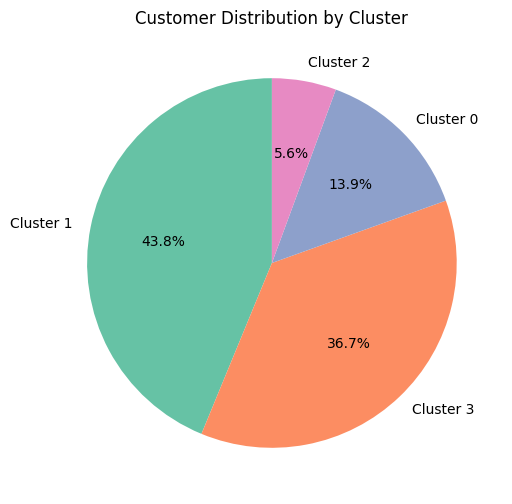

In [29]:
plt.figure(figsize=(6, 6))
cluster_counts = clustered_data["Cluster"].value_counts()
plt.pie(cluster_counts, labels=[f"Cluster {i}" for i in cluster_counts.index],
        autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set2"))
plt.title("Customer Distribution by Cluster")
plt.show()

## 6️⃣ Save Full Segmented Dataset

In [19]:
segmented_data = data.copy()
segmented_data["Cluster_KMeans"] = labels_kmeans
segmented_data["Cluster_DBSCAN"] = labels_dbscan

segmented_data.to_csv("data/customer_segments.csv", index=False)
print("✅ Segmented customer data saved to 'data/customer_segments.csv'")

✅ Segmented customer data saved to 'data/customer_segments.csv'


## 7️⃣ AI Model: Predict Cluster for New Customers

In [20]:
print("\n🔹 Training AI model to predict clusters...")

X_train, X_test, y_train, y_test = train_test_split(X_scaled, labels_kmeans, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Save model
joblib.dump(rf_model, "data/ai_cluster_predictor.pkl")
print("✅ AI model saved as 'data/ai_cluster_predictor.pkl'")

# Evaluate on test set
test_accuracy = rf_model.score(X_test, y_test)
print(f"\n🎯 AI Model Accuracy on test set: {test_accuracy:.2f}")


🔹 Training AI model to predict clusters...
✅ AI model saved as 'data/ai_cluster_predictor.pkl'

🎯 AI Model Accuracy on test set: 0.95


##  8️⃣ Predict New Customer Example

In [21]:
example_customer = [data.mean().tolist()]
predicted_cluster = rf_model.predict(example_customer)
print(f"\n🤖 Example Prediction → This new customer belongs to Cluster {predicted_cluster[0]}")

print("\n🎉 All steps completed successfully!")


🤖 Example Prediction → This new customer belongs to Cluster 2

🎉 All steps completed successfully!
